# Imports + Load Data

In [3]:
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("../data/processed/cleaned_fake_news.csv")

df = df.dropna(subset=["clean_text"])
df = df[df["clean_text"].str.strip() != ""]

X = df["clean_text"].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 50106
Test size: 12527


# Tokenization

In [4]:
max_words = 20000
max_len = 300

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# Load GloVe Embeddings

In [6]:
embeddings_index = {}

with open("../data/glove/glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

embedding_dim = 100
word_index = tokenizer.word_index

embedding_matrix = np.zeros((max_words, embedding_dim))

for word, i in word_index.items():
    if i < max_words:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

print("Embedding matrix created:", embedding_matrix.shape)

Embedding matrix created: (20000, 100)


# Build LSTM Model

In [7]:
model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    ),
    LSTM(128, dropout=0.3, recurrent_dropout=0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

# Training

In [8]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/3
705/705 ━━━━━━━━━━━━━━━━━━━━ 418s 587ms/step - accuracy: 0.8430 - loss: 0.3500 - val_accuracy: 0.8994 - val_loss: 0.2425
Epoch 2/3
705/705 ━━━━━━━━━━━━━━━━━━━━ 415s 589ms/step - accuracy: 0.9043 - loss: 0.2313 - val_accuracy: 0.9391 - val_loss: 0.1497
Epoch 3/3
705/705 ━━━━━━━━━━━━━━━━━━━━ 401s 569ms/step - accuracy: 0.9305 - loss: 0.1691 - val_accuracy: 0.9507 - val_loss: 0.1239


# Evaluation

In [9]:
y_pred = (model.predict(X_test_pad) > 0.5).astype("int32")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

392/392 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step
Accuracy: 0.9452382853037439

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      6924
           1       0.94      0.94      0.94      5603

    accuracy                           0.95     12527
   macro avg       0.94      0.94      0.94     12527
weighted avg       0.95      0.95      0.95     12527



# Confusion Matrix

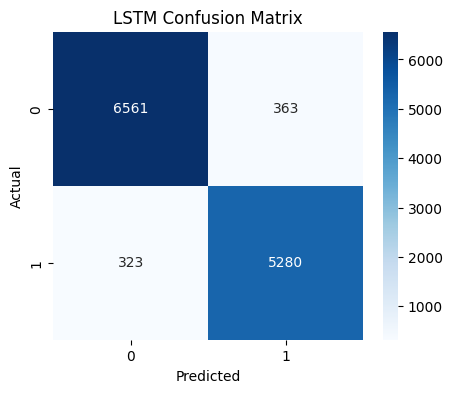

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Training Curve

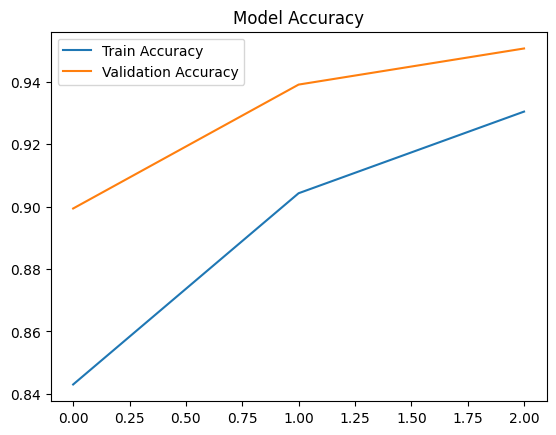

In [11]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.show()

# Explainability

In [12]:
def explain_text(text):
    
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=300)

    pred = model.predict(padded)[0][0]
    label = "Fake" if pred > 0.5 else "Real"

    words = text.lower().split()

    # keep only known words in tokenizer
    important_words = [
        w for w in words
        if w in tokenizer.word_index
    ]

    return label, important_words


# TEST EXAMPLE
sample = "Breaking news: shocking discovery about government corruption scandal"

label, reasons = explain_text(sample)

print("Prediction:", label)
print("Words contributing:", reasons)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Prediction: Fake
Words contributing: ['breaking', 'shocking', 'discovery', 'government', 'corruption', 'scandal']


# SAVE LSTM MODEL

In [13]:
import pickle
import os

os.makedirs("../outputs/models", exist_ok=True)

# SAVE LSTM MODEL
model.save("../outputs/models/lstm_model.h5")

# SAVE TOKENIZER
with open("../outputs/models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("LSTM model + tokenizer saved ✔")

LSTM model + tokenizer saved ✔
